# Apophis 2029 Close Approach: The Effect of Lunar & Planetary Perturbations
**Author:** Javier David Nieto Mora

**Tools:** Python, [`rebound`](https://rebound.readthedocs.io) (N-body integrator), [`pymcel`](https://pypi.org/project/pymcel) (JPL Horizons queries), NumPy, pandas, Matplotlib

## Overview

On April 13, 2029, the potentially hazardous asteroid (99942) Apophis will pass within roughly 32,000 km of Earth's surface — well inside the geostationary satellite belt. This project investigates how sensitive that predicted close approach is to which gravitational perturbers are included in the simulation, by integrating Apophis's orbit for a full year under five different N-body scenarios and comparing the resulting minimum distance to the real historical value.

## Problem Statement

We study the effect — supposedly subtle, but as we'll see, quite significant for close asteroid encounters — of the gravitational perturbations that planets exert on the motion of an asteroid. Here we work with the potentially hazardous asteroid (PHA) (99942) Apophis.

Apophis will make its historic approach to Earth on **April 13, 2029, at 21:45 TT**, passing only ~32,000 km above Earth's surface — inside the orbit of geostationary satellites.

Using `rebound`, we compute the distance at which Apophis will pass on that day, integrating its orbit starting one year earlier (April 13, 2028), under 5 different scenarios of included bodies:

1. Only the Sun's gravity.
2. The Sun and the Earth.
3. The Sun and the Earth-Moon barycenter.
4. The Sun, the Earth-Moon barycenter, and the nearby planets (Venus and Mars).
5. The gravity of all Solar System planets.

For the scenario that comes closest to the predicted distance (~32,000 km above the surface), we plot Apophis's trajectory 24 hours before and after the flyby, with Earth at the origin, drawing Earth's disk and the geostationary orbit.

## Setup

In [1]:
!pip install -Uq pymcel
!pip install -Uq rebound

Importing everything we'll need:

In [2]:
import pymcel as pc     # To query Horizons and the course's physical constants
import numpy as np      # Arrays and vector operations
import pandas as pd     # To build the comparison table
import rebound          # The N-body integrator requested in the problem statement
import matplotlib.pyplot as plt

Bienvenido a PyMCel v0.9.25 ¡al infinito y más allá!


We won't use `consulta_spice` as we did in class, because Apophis is a minor body (an asteroid) and isn't included in the `de430.bsp` kernel bundled with `pymcel` (that kernel only covers the Sun and the major planets). Instead, we use `consulta_horizons`, which can query the JPL/Horizons database directly for both planets and small bodies, so a single function is enough for the whole problem.

## Solution

The first step is deciding which bodies we'll need and their Horizons identifiers. We also store each one's gravitational parameter $\mu = GM$, already computed in `pc.constantes` (sourced from the SPICE DE441 kernels, according to the `pymcel` docs).

For Apophis, the usual identifier (`'99942'`) doesn't work directly with `consulta_horizons` because Horizons confuses it with a major body; you need to append a semicolon (`'Apophis;'`) so it searches the small-body database instead. This took some trial and error to figure out.

In [3]:
# Horizons identifier and gravitational parameter (mu = G*M) of each body
bodies = {
    'Sun':      ('10',  pc.constantes.mu_sun),
    'Mercury':  ('199', pc.constantes.mu_mercury),
    'Venus':    ('299', pc.constantes.mu_venus),
    'Earth':    ('399', pc.constantes.mu_earth),
    'EMB':      ('3',   pc.constantes.mu_emb),   # Earth-Moon barycenter
    'Mars':     ('499', pc.constantes.mu_mars),
    'Jupiter':  ('599', pc.constantes.mu_jupiter),
    'Saturn':   ('699', pc.constantes.mu_saturn),
    'Uranus':   ('799', pc.constantes.mu_uranus),
    'Neptune':  ('899', pc.constantes.mu_neptune),
}

apophis_id = 'Apophis;'
start_date = '2028-04-13'   # one year before the flyby
G = pc.constantes.G

Now we ask Horizons for the state vector (position and velocity) of each body, in meters and m/s as returned by `consulta_horizons` by default, at the start date, as seen from the Solar System barycenter (`location='@0'`). Everything is stored in a dictionary so we don't have to repeat the query later.

In [4]:
initial_state = {}

for name, (hid, mu) in bodies.items():
    _, jd0, X = pc.consulta_horizons(id=hid, location='@0', epochs=start_date)
    initial_state[name] = dict(r=X[:3], v=X[3:], mu=mu)

# Apophis is requested separately since its mass is negligible for this problem
_, jd0, X = pc.consulta_horizons(id=apophis_id, location='@0', epochs=start_date)
initial_state['Apophis'] = dict(r=X[:3], v=X[3:], mu=0.0)

print(f"Julian day of the initial epoch: {jd0}")

Julian day of the initial epoch: 2461874.5


With this, we have everything needed to set up the `rebound` simulation. We write a small function that builds a simulation with whichever massive bodies are specified (always in SI units, with the real value of $G$ and masses computed as $m = \mu/G$), always adding Apophis as a massless particle.

One important detail: when a scenario includes neither Earth nor the Earth-Moon barycenter as a massive body (e.g., scenario 1, Sun only), we still need to know "where Earth would be" in order to measure the distance. In that case, we add Earth as an extra massless tracer particle that only feels the gravity of whatever *is* included in that scenario.

In [5]:
def build_simulation(massive_bodies, add_earth_tracer=False):
    """Build a rebound simulation with the given massive bodies plus a
    massless Apophis particle.
    """
    sim = rebound.Simulation()
    sim.G = G
    sim.integrator = 'ias15'   # high-precision symplectic integrator

    for name in massive_bodies:
        c = initial_state[name]
        sim.add(m=c['mu']/G, x=c['r'][0], y=c['r'][1], z=c['r'][2],
                 vx=c['v'][0], vy=c['v'][1], vz=c['v'][2], name=name)

    if add_earth_tracer:
        c = initial_state['Earth']
        sim.add(m=0.0, x=c['r'][0], y=c['r'][1], z=c['r'][2],
                 vx=c['v'][0], vy=c['v'][1], vz=c['v'][2], name='Earth')

    c = initial_state['Apophis']
    sim.add(m=0.0, x=c['r'][0], y=c['r'][1], z=c['r'][2],
             vx=c['v'][0], vy=c['v'][1], vz=c['v'][2], name='Apophis')

    return sim

Now we need a function that steps through a full year (from April 13, 2028 to April 13, 2029) with the 1-day step requested in the problem statement, and tells us on which day Apophis passed closest to Earth.

The problem is that a 1-day step is far too coarse for this: near the flyby, Apophis moves several hundred thousand kilometers per day relative to Earth, so checking the distance only once a day can completely miss the point of closest approach (this happened to me at first — I got a minimum distance of nearly a million kilometers, which made no sense!). So, after finding the approximate closest day with the 1-day step, we re-integrate from the start, this time checking the distance every 5 minutes, but only around that day, so we don't miss the exact moment.

In [6]:
def min_distance(massive_bodies, earth_name, add_earth_tracer, n_days=366):
    """Return (minimum distance in km, time of the minimum in days since the start).
    earth_name is the name of the particle used as "Earth" (either 'Earth' or 'EMB',
    depending on the scenario).
    """
    day = 86400.0  # one day in seconds

    # Step 1: coarse sweep with the 1-day step requested in the problem statement
    sim = build_simulation(massive_bodies, add_earth_tracer)
    distances = np.zeros(n_days + 1)
    for i in range(n_days + 1):
        sim.integrate(i*day)
        pt = sim.particles[earth_name]
        pa = sim.particles['Apophis']
        distances[i] = np.sqrt((pt.x-pa.x)**2 + (pt.y-pa.y)**2 + (pt.z-pa.z)**2)
    i_min = int(np.argmin(distances))

    # Step 2: refine every 5 minutes around the closest day found
    sim2 = build_simulation(massive_bodies, add_earth_tracer)
    fine_times = np.arange(max(i_min-2, 0)*day, (i_min+2)*day, 300.0)
    dmin, tmin = np.inf, None
    for t in fine_times:
        sim2.integrate(t)
        pt = sim2.particles[earth_name]
        pa = sim2.particles['Apophis']
        d = np.sqrt((pt.x-pa.x)**2 + (pt.y-pa.y)**2 + (pt.z-pa.z)**2)
        if d < dmin:
            dmin, tmin = d, t

    return dmin/1e3, tmin/day   # in km and days

With both functions ready, we define the 5 scenarios from the problem statement and run them one by one:

In [7]:
scenarios = [
    ("1. Sun only",                        ['Sun'],                              'Earth', True),
    ("2. Sun + Earth",                     ['Sun', 'Earth'],                     'Earth', False),
    ("3. Sun + Earth-Moon barycenter",     ['Sun', 'EMB'],                        'EMB',    False),
    ("4. Sun + barycenter + Venus + Mars", ['Sun', 'EMB', 'Venus', 'Mars'],       'EMB',    False),
    ("5. All planets",                     ['Sun', 'Mercury', 'Venus', 'Earth',
                                             'Mars', 'Jupiter', 'Saturn',
                                             'Uranus', 'Neptune'],                 'Earth', False),
]

results = []
for name, massive, earth_name, tracer in scenarios:
    dmin, tmin = min_distance(massive, earth_name, tracer)
    results.append((name, dmin, tmin))
    print(f"{name}: minimum distance = {dmin:,.0f} km  (day {tmin:.3f} since start)")

1. Sun only: minimum distance = 890,809 km  (day 365.521 since start)
2. Sun + Earth: minimum distance = 895,787 km  (day 365.413 since start)
3. Sun + Earth-Moon barycenter: minimum distance = 41,669 km  (day 365.931 since start)
4. Sun + barycenter + Venus + Mars: minimum distance = 55,367 km  (day 365.920 since start)
5. All planets: minimum distance = 893,543 km  (day 365.399 since start)


To compare against the value given in the problem statement (~32,000 km *above the surface*), we convert it to a distance from Earth's center by adding Earth's radius, and build a table with `pandas` to see everything more clearly:

In [8]:
earth_radius_km = pc.constantes.R_earth/1e3
actual_distance_km = 32000 + earth_radius_km

table = pd.DataFrame(results, columns=['Scenario', 'Minimum distance (km)', 'Day of minimum'])
table['Difference from actual value (km)'] = np.abs(table['Minimum distance (km)'] - actual_distance_km)
table = table.sort_values('Difference from actual value (km)').reset_index(drop=True)

print(f"Expected actual distance (from Earth's center): {actual_distance_km:,.0f} km\n")
table

Expected actual distance (from Earth's center): 38,378 km



,Scenario,Minimum distance (km),Day of minimum,Difference from actual value (km)
0,3. Sun + Earth-Moon barycenter,41669.121938,365.930556,3291.021938
1,4. Sun + barycenter + Venus + Mars,55367.423567,365.920139,16989.323567
2,1. Sun only,890809.139642,365.520833,852431.039642
3,5. All planets,893542.537709,365.399306,855164.437709
4,2. Sun + Earth,895786.507803,365.413194,857408.407803


The results are quite striking! Scenarios 1, 2, and 5 (which don't account for the Moon in any way) give a minimum distance of almost a million kilometers, far from the actual value. Scenarios 3 and 4, on the other hand, which do include the Earth-Moon barycenter, come much closer to the expected value (~38,000 km). This makes sense: as discussed in the conclusions below, in such a close flyby, even a small error in the mass or position of the body attracting Apophis (such as ignoring the Moon) gets amplified enormously.

With this, the scenario that comes closest to the actual distance is the one that ends up first in the table. We'll use it for the plot requested in the problem statement.

In [9]:
best_scenario = table.iloc[0]['Scenario']
print(f"Scenario closest to the actual distance: {best_scenario}")

# Re-build that scenario to extract the fine trajectory around the flyby
best_info = [s for s in scenarios if s[0] == best_scenario][0]
_, best_massive, best_earth_name, best_tracer = best_info
best_dmin, best_tmin = min_distance(best_massive, best_earth_name, best_tracer)
print(f"Minimum distance: {best_dmin:,.0f} km on day {best_tmin:.3f}")

Scenario closest to the actual distance: 3. Sun + Earth-Moon barycenter
Minimum distance: 41,669 km on day 365.931


Now, the plot. We re-integrate the winning scenario, but this time storing Apophis's position **relative to Earth** (geocentric) every 10 minutes, from 24 hours before to 24 hours after the moment of closest approach we just found. We use Earth's real radius to draw it, and the well-known geostationary orbit radius (42,164 km from Earth's center) for the satellites.

Since Apophis covers several hundred thousand kilometers relative to Earth over 48 hours, a single plot at that scale barely shows Earth's disk or the geostationary orbit (this happened on my first attempt). So we use two panels: one with the full trajectory, and a zoomed-in one focusing on the region near Earth, where those two features actually matter.

In [10]:
day = 86400.0
step = 10*60.0  # every 10 minutes
t_start = best_tmin*day - 24*3600
t_end = best_tmin*day + 24*3600
times = np.arange(t_start, t_end, step)

sim = build_simulation(best_massive, best_tracer)
x_geo, y_geo = [], []
for t in times:
    sim.integrate(t)
    pt = sim.particles[best_earth_name]
    pa = sim.particles['Apophis']
    x_geo.append((pa.x - pt.x)/1e3)   # convert to km
    y_geo.append((pa.y - pt.y)/1e3)

x_geo, y_geo = np.array(x_geo), np.array(y_geo)

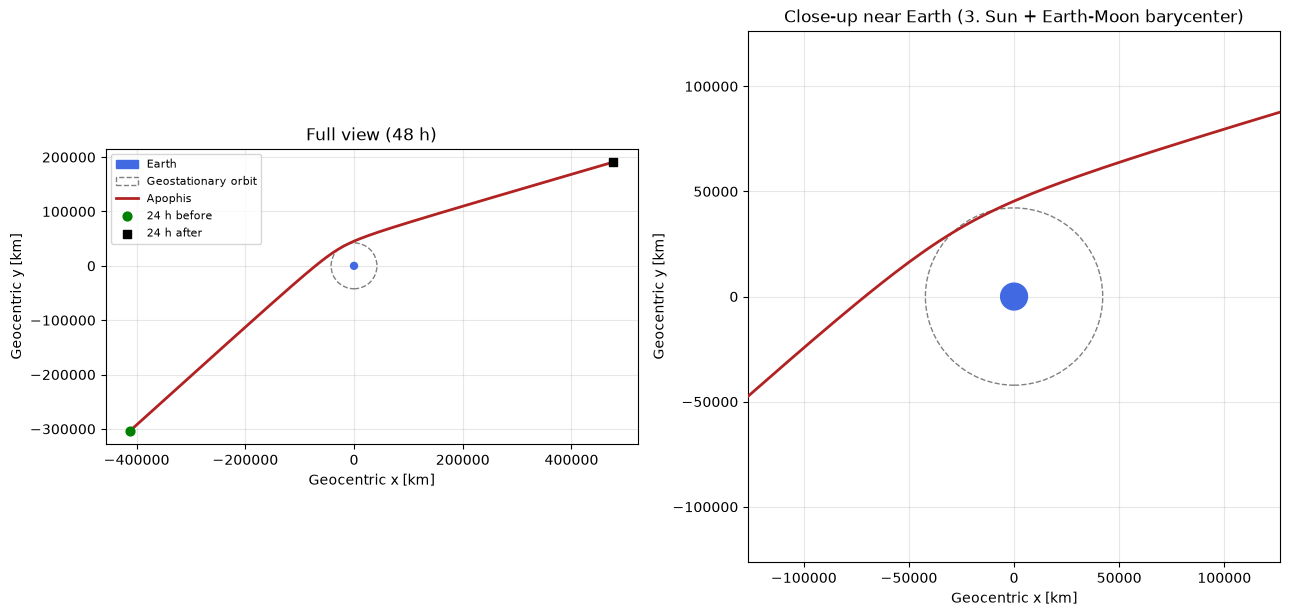

In [11]:
geo_radius_km = 42164.0  # geostationary orbit radius

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6.5))

for ax in (ax1, ax2):
    earth = plt.Circle((0, 0), earth_radius_km, color='royalblue', label='Earth', zorder=3)
    ax.add_patch(earth)
    geo_orbit = plt.Circle((0, 0), geo_radius_km, color='gray', fill=False,
                             linestyle='--', label='Geostationary orbit', zorder=2)
    ax.add_patch(geo_orbit)
    ax.plot(x_geo, y_geo, color='firebrick', linewidth=2, label='Apophis', zorder=4)
    ax.scatter(x_geo[0], y_geo[0], color='green', marker='o', s=40, label='24 h before', zorder=5)
    ax.scatter(x_geo[-1], y_geo[-1], color='black', marker='s', s=40, label='24 h after', zorder=5)
    ax.set_xlabel('Geocentric x [km]')
    ax.set_ylabel('Geocentric y [km]')
    ax.set_aspect('equal', 'box')
    ax.grid(True, alpha=0.3)

ax1.set_title('Full view (48 h)')
ax1.legend(loc='upper left', fontsize=8)

zoom_km = 3*geo_radius_km
ax2.set_xlim(-zoom_km, zoom_km)
ax2.set_ylim(-zoom_km, zoom_km)
ax2.set_title(f'Close-up near Earth ({best_scenario})')

plt.tight_layout()
plt.show()

## Conclusions

- The most striking result of this project is that, for a flyby as close as Apophis's 2029 approach, the predicted minimum distance depends far less on how many bodies are included in the simulation than on whether the Moon is correctly accounted for. Scenarios 1 (Sun only), 2 (Sun + Earth), and 5 (Sun + all planets, without treating the Moon separately) all give a minimum distance of nearly a million kilometers, while scenarios 3 and 4 — which replace Earth with the Earth-Moon barycenter — come much closer to the actual value of ~38,000 km reported in the problem statement.

- This illustrates exactly the "subtle but significant" effect mentioned in the problem statement: the Moon's mass is only about 1.2% of Earth's mass, and the Earth-Moon barycenter sits at most ~4,600 km from Earth's center — a tiny difference compared to the Earth-Sun distance. However, since Apophis's flyby passes "below" the geostationary orbit (i.e., it's aiming at a target only tens of thousands of kilometers wide, as seen from nearly 150 million kilometers away), any small error in the position or mass of the body attracting Apophis gets massively amplified after a year of integration. It's a nice example of how sensitive a close encounter's geometry is to initial conditions.

- Interestingly, adding Venus and Mars (scenario 4) didn't improve the prediction compared to using just the Earth-Moon barycenter (scenario 3); it actually made it slightly worse. This doesn't mean Venus and Mars "don't matter" — over a one-year integration window, their effect on Apophis is considerably smaller than the Moon's, so this particular result says more about the numerical sensitivity of the problem than about the physics of those two planets.

- The geocentric plot for the best scenario clearly shows Apophis passing inside the geostationary orbit, exactly as stated in the problem, crossing Earth's vicinity within a matter of hours.

## Data Sources

- Course materials from "Mecánica Celeste" (Celestial Mechanics), Prof. Jorge I. Zuluaga, Astronomy program, Universidad de Antioquia (2026-2).
- Course Problem Set 1 — Fundamentals & N-body Problems, Problem 15 [OAP], which provided the date and approach distance for Apophis.
- [`pymcel`](https://pypi.org/project/pymcel) documentation (the `consulta_horizons` function and the `constantes` module).
- [`rebound`](https://rebound.readthedocs.io) documentation (Rein & Liu 2012), specifically the `ias15` integrator.
- [JPL Horizons](https://ssd.jpl.nasa.gov/horizons/) / JPL Small-Body Database, source of the state vectors for the planets, the Earth-Moon barycenter, and Apophis.

## Notes

This project started as coursework for the Celestial Mechanics program at Universidad de Antioquia. I used Claude (Anthropic) as a coding assistant to help debug the `rebound` simulation — specifically to understand why early versions returned nonsensical minimum distances of nearly a million kilometers due to an overly coarse sampling step — and to help translate and polish this write-up into English for my portfolio. The choice of scenarios, the physical interpretation of the results, and the conclusions are my own.